<a href="https://colab.research.google.com/github/felipemingo321/actuarial-portfolio/blob/main/chain_ladder_bf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Proyecto Actuarial: Estimación de Reservas IBNR
## Métodos Chain-Ladder y Bornhuetter-Ferguson

#Autor: Felipe Mingo
#Fecha: Marzo 2026
#Descripción:
#Este notebook implementa dos métodos clásicos para la estimación de reservas de siniestros pendientes (IBNR) en seguros no vida. Se parte de un triángulo de siniestros incremental simulado y se aplican:
#- Chain-Ladder (determinístico) mediante cálculo manual.
#- Bornhuetter-Ferguson combinando información a priori con el patrón de desarrollo observado.

#El objetivo es mostrar comprensión técnica, capacidad de programación en Python y habilidades de visualización para su presentación en un portafolio GitHub.

In [ ]:
# Instalamos las librerías necesarias (ejecutar una sola vez)
!pip install chainladder pandas matplotlib seaborn numpy

# Nota: 'seaborn' es para gráficos más estéticos. Si tienes error, verifica el nombre.

  Using cached chainladder-0.9.1-py3-none-any.whl.metadata (6.9 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.9/151.9 kB 12.5 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import chainladder as cl
from scipy import stats

# Configuración de estilo para gráficos
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
np.random.seed(42)  # para reproducibilidad

In [ ]:
### 1. Simulación de un triángulo de siniestros incremental

#Para poder demostrar los métodos sin disponer de datos reales, generamos un triángulo artificial con distribución Poisson (frecuencia de siniestros) y lo convertimos en un triángulo acumulado. La parte inferior se oculta (valores NaN) para simular la información incompleta típica en la práctica.

In [ ]:
# Parámetros del triángulo
años_origen = 10
años_desarrollo = 10

# Generamos valores aleatorios (enteros) y convertimos a float para poder poner NaN
incr = np.random.poisson(lam=100, size=(años_origen, años_desarrollo)).astype(float)

# Convertimos en triángulo inferior: para el año de origen i, ocultamos desde la columna (años_origen - i) en adelante
for i in range(años_origen):
    incr[i, años_origen - i:] = np.nan

# Creamos DataFrame con índices claros
incr_df = pd.DataFrame(incr,
                       index=pd.Index(range(1, años_origen+1), name='Año origen'),
                       columns=pd.Index(range(1, años_desarrollo+1), name='Año desarrollo'))

print("🔹 Triángulo incremental (valores observados):")
print(incr_df)

# Calculamos el triángulo acumulado
acum_df = incr_df.cumsum(axis=1)
print("\n🔹 Triángulo acumulado:")
print(acum_df)

🔹 Triángulo incremental (valores observados):
Año desarrollo     1      2      3      4      5      6     7      8      9   \
Año origen                                                                     
1                96.0  107.0   88.0  103.0  111.0   90.0  94.0   98.0  103.0   
2                99.0   90.0  103.0  103.0   94.0  105.0  86.0   92.0   94.0   
3               103.0   84.0   76.0   97.0  111.0   93.0  87.0  108.0    NaN   
4                96.0  113.0   95.0   94.0  107.0  114.0  86.0    NaN    NaN   
5                94.0  116.0   97.0   91.0   94.0  118.0   NaN    NaN    NaN   
6                91.0  110.0   98.0   86.0  121.0    NaN   NaN    NaN    NaN   
7               103.0   78.0  116.0   88.0    NaN    NaN   NaN    NaN    NaN   
8               105.0  100.0  104.0    NaN    NaN    NaN   NaN    NaN    NaN   
9                84.0  115.0    NaN    NaN    NaN    NaN   NaN    NaN    NaN   
10              106.0    NaN    NaN    NaN    NaN    NaN   NaN    NaN    N

In [ ]:
## 2. Chain-Ladder manual

#El método Chain-Ladder proyecta el triángulo acumulado utilizando factores de desarrollo (Link Ratios) calculados a partir de las columnas completas. Se asume que el patrón de desarrollo pasado se mantiene en el futuro.

In [ ]:
# --- Cálculo de factores de desarrollo (promedio simple) ---
factores = {}
for j in range(1, años_desarrollo):
    col_ant = acum_df.columns[j-1]
    col_act = acum_df.columns[j]
    datos = acum_df[[col_ant, col_act]].dropna()
    if len(datos) > 0:
        factor = datos[col_act].sum() / datos[col_ant].sum()
        factores[f"{col_ant}→{col_act}"] = factor

print("📊 Factores de desarrollo (LDF):")
for k, v in factores.items():
    print(f"{k}: {v:.4f}")

# --- Proyección del triángulo acumulado ---
acum_proy = acum_df.copy()
for j in range(1, años_desarrollo):
    col_ant = acum_proy.columns[j-1]
    col_act = acum_proy.columns[j]
    factor = factores.get(f"{col_ant}→{col_act}", 1.0)
    for i in range(años_origen):
        if pd.isna(acum_proy.iloc[i, j]):
            acum_proy.iloc[i, j] = acum_proy.iloc[i, j-1] * factor

print("\n🔹 Triángulo acumulado proyectado (Chain-Ladder):")
print(acum_proy)

# --- Cálculo de IBNR por año de origen y total ---
# IBNR = diferencia entre el último valor proyectado y el último valor observado
ultimo_observado = acum_df.apply(lambda row: row[row.last_valid_index()] if row.last_valid_index() else 0, axis=1)
ultimo_proyectado = acum_proy.iloc[:, -1]  # última columna (años_desarrollo)
ibnr_cl = ultimo_proyectado - ultimo_observado
ibnr_cl_total = ibnr_cl.sum()

print("\n💰 IBNR estimado por año de origen (Chain-Ladder):")
print(ibnr_cl.round(2))
print(f"\n💰 IBNR total Chain-Ladder: {ibnr_cl_total:,.2f}")

📊 Factores de desarrollo (LDF):
1→2: 2.0482
2→3: 1.4902
3→4: 1.3225
4→5: 1.2738
5→6: 1.2112
6→7: 1.1488
7→8: 1.1475
8→9: 1.1264
9→10: 1.1056

🔹 Triángulo acumulado proyectado (Chain-Ladder):
Año desarrollo     1           2           3           4           5   \
Año origen                                                              
1                96.0  203.000000  291.000000  394.000000  505.000000   
2                99.0  189.000000  292.000000  395.000000  489.000000   
3               103.0  187.000000  263.000000  360.000000  471.000000   
4                96.0  209.000000  304.000000  398.000000  505.000000   
5                94.0  210.000000  307.000000  398.000000  492.000000   
6                91.0  201.000000  299.000000  385.000000  506.000000   
7               103.0  181.000000  297.000000  385.000000  490.420601   
8               105.0  205.000000  309.000000  408.638578  520.531888   
9                84.0  199.000000  296.553943  392.179228  499.565644   
10    

In [ ]:
## 3. Bornhuetter-Ferguson (BF)

#El método BF combina una estimación a priori de la siniestralidad final (basada en primas y una ratio esperada) con el patrón de desarrollo observado. La reserva se calcula como:

#{Reserva BF} = \left(1 - \frac{1}{\text{Factor acumulado hasta el final}}\right) \times \text{Pérdida última esperada}

#Para este ejemplo, supondremos primas y una ratio de siniestralidad esperada del 70%.

In [ ]:
# Simulamos primas para cada año de origen
np.random.seed(123)  # semilla diferente para distinguir
primas = np.random.uniform(800, 1200, size=años_origen)
ratio_esperado = 0.70
ultimo_esperado = primas * ratio_esperado

# Calculamos los factores acumulados hasta el final
# Para cada año de desarrollo j, necesitamos el factor que lleva de j al último desarrollo
factores_acum_final = {}
for j in range(1, años_desarrollo+1):
    factor_acum = 1.0
    for k in range(j, años_desarrollo):
        col_ant = acum_df.columns[k-1]
        col_act = acum_df.columns[k]
        factor_acum *= factores.get(f"{col_ant}→{col_act}", 1.0)
    factores_acum_final[j] = factor_acum

# Calculamos IBNR por año de origen con BF
ibnr_bf = {}
for i, idx in enumerate(acum_df.index):
    ultimo_periodo = acum_df.loc[idx].last_valid_index()
    if ultimo_periodo is None:
        continue
    j = int(ultimo_periodo)
    pct_desarrollado = 1 / factores_acum_final[j]
    reserva_bf = (1 - pct_desarrollado) * ultimo_esperado[i]
    ibnr_bf[idx] = reserva_bf

# Convertir a Serie para facilitar
ibnr_bf_serie = pd.Series(ibnr_bf, name='IBNR BF')
print("🔹 IBNR Bornhuetter-Ferguson por año de origen:")
print(ibnr_bf_serie.round(2))
print(f"\n💰 IBNR total BF: {ibnr_bf_serie.sum():,.2f}")

🔹 IBNR Bornhuetter-Ferguson por año de origen:
1       0.00
2      61.15
3     122.83
4     214.48
5     297.64
6     337.27
7     505.11
8     527.33
9     555.50
10    604.28
Name: IBNR BF, dtype: float64

💰 IBNR total BF: 3,225.58


In [ ]:
## 4. Comparación de resultados

#Ambos métodos producen estimaciones diferentes. Mientras Chain-Ladder se basa únicamente en los datos observados, BF incorpora un juicio experto (ratio esperado). En la práctica, se suelen comparar y promediar.

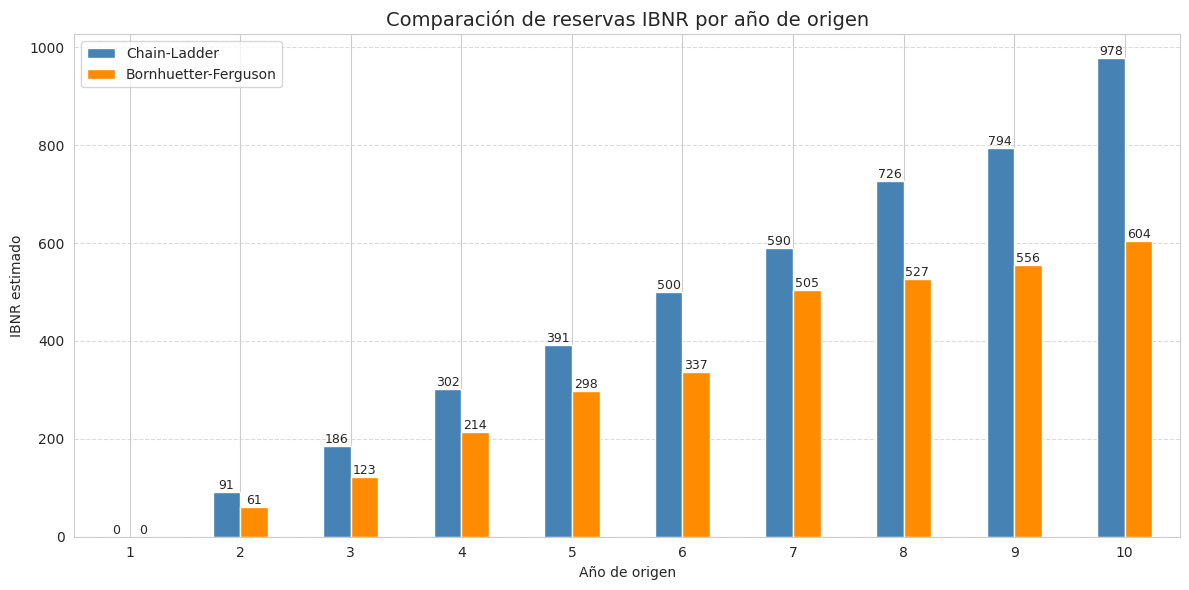

📌 IBNR Total Chain-Ladder: 4,560.13
📌 IBNR Total BF: 3,225.58
📌 Diferencia (BF - CL): -1,334.55


In [ ]:
# Creamos un DataFrame para comparar
comparacion = pd.DataFrame({
    'Chain-Ladder': ibnr_cl,
    'Bornhuetter-Ferguson': ibnr_bf_serie
})

# Gráfico de barras
ax = comparacion.plot(kind='bar', figsize=(12,6), color=['steelblue', 'darkorange'])
plt.title('Comparación de reservas IBNR por año de origen', fontsize=14)
plt.xlabel('Año de origen')
plt.ylabel('IBNR estimado')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Añadir valores sobre las barras
for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Mostrar totales
print(f"📌 IBNR Total Chain-Ladder: {ibnr_cl.sum():,.2f}")
print(f"📌 IBNR Total BF: {ibnr_bf_serie.sum():,.2f}")
print(f"📌 Diferencia (BF - CL): {ibnr_bf_serie.sum() - ibnr_cl.sum():,.2f}")

In [ ]:
## Conclusiones

#- Chain-Ladder es un método puramente empírico; sensible a la estabilidad de los factores.
#- Bornhuetter-Ferguson permite incorporar información externa, útil cuando los datos son escasos o volátiles.
#- En un entorno real, se utilizarían múltiples métodos y se validaría con backtesting.

#Este proyecto demuestra la capacidad de implementar modelos actuariales en Python, manipular datos tabulares y comunicar resultados visualmente.